In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import timm
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import gc

# Clear GPU memory first
torch.cuda.empty_cache()
gc.collect()

# Define the transformations for the dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),  # Reduced rotation
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),  # Reduced jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define the paths to the dataset
train_dir = '/kaggle/input/trunkd/DLD_FinalDataset_224_spit/train'
val_dir = '/kaggle/input/trunkd/DLD_FinalDataset_224_spit/val'
test_dir = '/kaggle/input/trunkd/DLD_FinalDataset_224_spit/test'

# Load the datasets
train_data = datasets.ImageFolder(root=train_dir, transform=transform)
val_data = datasets.ImageFolder(root=val_dir, transform=transform)
test_data = datasets.ImageFolder(root=test_dir, transform=transform)

# Create DataLoader with smaller batch size
batch_size = 16  # Reduced from 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Check the class names
class_names = train_data.classes
print(f"Classes: {class_names}")
print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")



Classes: ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']
Training samples: 3104
Validation samples: 443
Test samples: 890


# Resnet model training

In [25]:
# Use ResNet-101 model from timm
model = timm.create_model('resnet101', pretrained=True, num_classes=len(class_names))

# Move the model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")
print(f"Model: ResNet-101")

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Use a learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Track the best model
best_model_wts = model.state_dict()
best_acc = 0.0

# Training and validation loop
num_epochs = 15  # More epochs for better learning
train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch + 1}/{num_epochs}')
    print('-' * 50)
    
    # Training phase
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    pbar = tqdm(train_loader, desc=f'Training')
    
    for batch_idx, (inputs, labels) in enumerate(pbar):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping to prevent explosions
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_preds += torch.sum(preds == labels.data)
        total_preds += labels.size(0)
        
        # Update progress bar
        current_loss = running_loss / (batch_idx + 1)
        current_acc = float(correct_preds) / total_preds
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.4f}'
        })

    # Calculate training metrics
    train_loss = running_loss / len(train_loader)
    train_acc = correct_preds.double() / total_preds
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc.cpu())
    
    print(f'Training Loss: {train_loss:.4f} | Training Accuracy: {train_acc:.4f}')
    
    # Validation phase
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_preds += torch.sum(preds == labels.data)
            total_preds += labels.size(0)
    
    # Calculate validation metrics
    val_loss = running_loss / len(val_loader)
    val_acc = correct_preds.double() / total_preds
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc.cpu())
    
    print(f'Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}')
    
    # Save the best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = model.state_dict()
        torch.save(model.state_dict(), 'best_model_resnet101.pth')
        print(f"🎯 New best model saved! Accuracy: {best_acc:.4f}")
    
    # Learning rate scheduling
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    print(f'Learning Rate: {current_lr:.6f}')
    
    # Clear memory
    torch.cuda.empty_cache()



Using device: cuda
Model: ResNet-101

Epoch 1/15
--------------------------------------------------


Training: 100%|██████████| 194/194 [00:55<00:00,  3.53it/s, loss=0.9252, acc=0.6356]


Training Loss: 0.9252 | Training Accuracy: 0.6356
Validation Loss: 0.5623 | Validation Accuracy: 0.7968
🎯 New best model saved! Accuracy: 0.7968
Learning Rate: 0.000976

Epoch 2/15
--------------------------------------------------


Training: 100%|██████████| 194/194 [00:54<00:00,  3.55it/s, loss=0.4300, acc=0.8608]


Training Loss: 0.4300 | Training Accuracy: 0.8608
Validation Loss: 0.3680 | Validation Accuracy: 0.8668
🎯 New best model saved! Accuracy: 0.8668
Learning Rate: 0.000905

Epoch 3/15
--------------------------------------------------


...

Training Loss: 0.0314 | Training Accuracy: 0.9887
Validation Loss: 0.0664 | Validation Accuracy: 0.9774
Learning Rate: 0.000206

Epoch 14/15
--------------------------------------------------


Training: 100%|██████████| 194/194 [00:55<00:00,  3.51it/s, loss=0.0388, acc=0.9884]


Training Loss: 0.0388 | Training Accuracy: 0.9884
Validation Loss: 0.1447 | Validation Accuracy: 0.9594
Learning Rate: 0.000345

Epoch 15/15
--------------------------------------------------


Training: 100%|██████████| 194/194 [00:55<00:00,  3.51it/s, loss=0.0426, acc=0.9868]


Training Loss: 0.0426 | Training Accuracy: 0.9868
Validation Loss: 0.1488 | Validation Accuracy: 0.9594
Learning Rate: 0.000500


# Model Evaluation

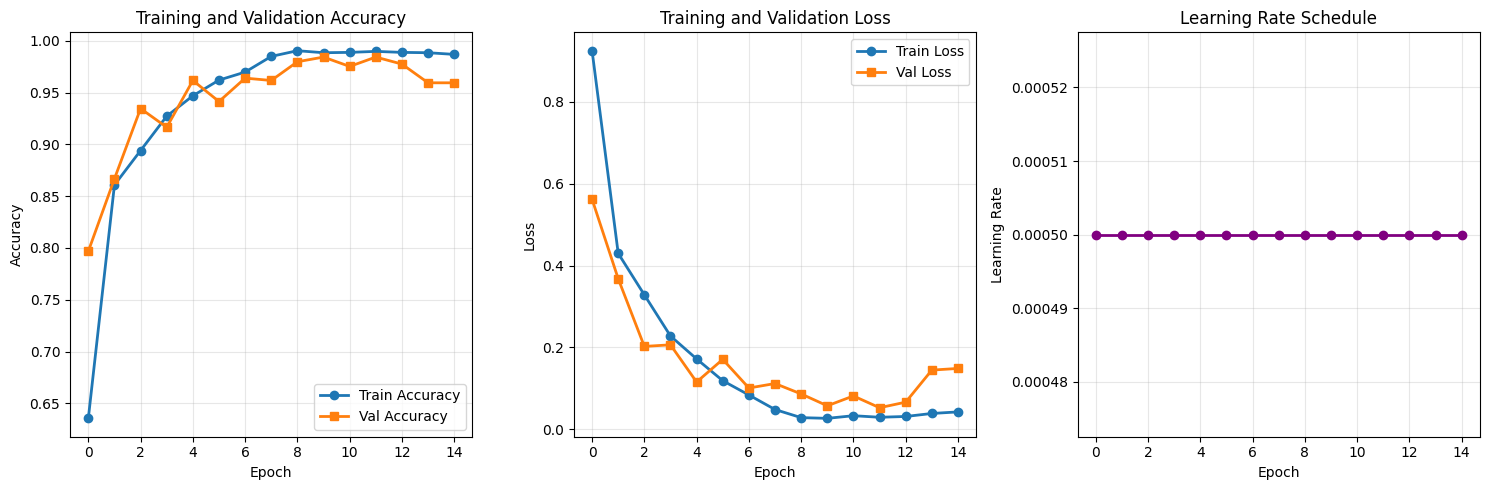


FINAL MODEL EVALUATION


Testing: 100%|██████████| 56/56 [00:13<00:00,  4.29it/s]



📊 Final Results:
Best Validation Accuracy: 0.9842
Test Accuracy: 0.9472

📋 Detailed Classification Report:
                     precision    recall  f1-score   support

    ALGAL_LEAF_SPOT     0.9038    0.9592    0.9307       147
ALLOCARIDARA_ATTACK     0.9667    0.9508    0.9587       183
       HEALTHY_LEAF     0.9159    1.0000    0.9561       196
        LEAF_BLIGHT     0.9731    0.9628    0.9679       188
PHOMOPSIS_LEAF_SPOT     0.9805    0.8580    0.9152       176

           accuracy                         0.9472       890
          macro avg     0.9480    0.9461    0.9457       890
       weighted avg     0.9492    0.9472    0.9468       890



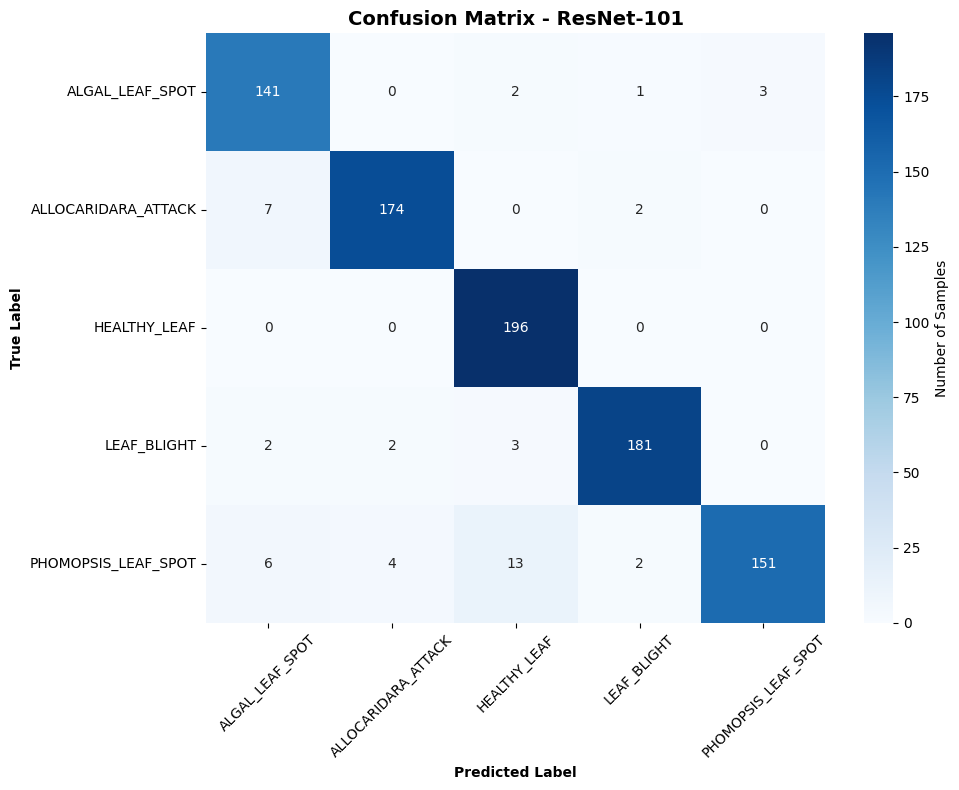


🎯 Per-Class Accuracy:
ALGAL_LEAF_SPOT          : 0.9592 (141/147)
ALLOCARIDARA_ATTACK      : 0.9508 (174/183)
HEALTHY_LEAF             : 1.0000 (196/196)
LEAF_BLIGHT              : 0.9628 (181/188)
PHOMOPSIS_LEAF_SPOT      : 0.8580 (151/176)

✅ Training completed successfully!
💾 Best model saved as: 'best_model_resnet101.pth'


In [26]:
# Load the best model
model.load_state_dict(best_model_wts)

# Plot results
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot([acc.item() for acc in train_acc_history], label='Train Accuracy', marker='o', linewidth=2)
plt.plot([acc.item() for acc in val_acc_history], label='Val Accuracy', marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(train_loss_history, label='Train Loss', marker='o', linewidth=2)
plt.plot(val_loss_history, label='Val Loss', marker='s', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Learning rate curve
lrs = [scheduler.get_last_lr()[0] for _ in train_acc_history]
plt.plot(lrs, color='purple', marker='o', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test the model
print("\n" + "="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Calculate test accuracy
test_accuracy = sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)

print(f"\n📊 Final Results:")
print(f"Best Validation Accuracy: {best_acc:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Samples'})
plt.title('Confusion Matrix - ResNet-101', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\n🎯 Per-Class Accuracy:")
class_correct = np.zeros(len(class_names))
class_total = np.zeros(len(class_names))

for i in range(len(class_names)):
    mask = np.array(all_labels) == i
    if np.sum(mask) > 0:
        class_correct[i] = np.sum(np.array(all_preds)[mask] == i)
        class_total[i] = np.sum(mask)
        accuracy = class_correct[i] / class_total[i]
        print(f"{class_names[i]:<25}: {accuracy:.4f} ({class_correct[i]:.0f}/{class_total[i]:.0f})")

print(f"\n✅ Training completed successfully!")
print(f"💾 Best model saved as: 'best_model_resnet101.pth'")


# Prediction

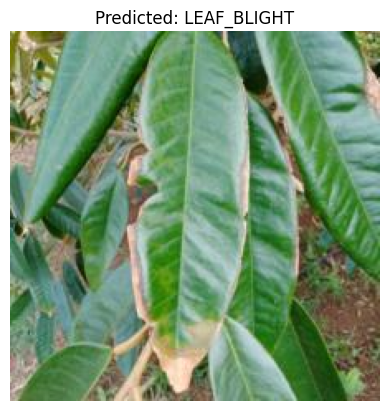

In [27]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import timm

# Function to load the saved model
def load_model(model_path='best_model_resnet101.pth', num_classes=5):
    model = timm.create_model('resnet101', pretrained=True, num_classes=num_classes)
    model.load_state_dict(torch.load(model_path))  # Load the best saved model
    model.eval()  # Set the model to evaluation mode
    return model

# Function to predict a single image
def predict_image(image_path, model, device):
    # Define the transformations to apply the same preprocessing as during training
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize the image to match the model's input size
        transforms.ToTensor(),  # Convert the image to a tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize the image
    ])
    
    # Open and transform the image
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0)  # Add batch dimension
    
    # Move the image tensor to the same device (GPU or CPU)
    image = image.to(device)
    model = model.to(device)
    
    # Perform the forward pass to get predictions
    with torch.no_grad():  # No need to compute gradients for inference
        outputs = model(image)
        _, preds = torch.max(outputs, 1)  # Get the predicted class with the highest score
    
    return preds.item()

# Function to display the image and predicted class
def display_prediction(image_path, predicted_class, class_names):
    # Open and display the image
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {class_names[predicted_class]}")
    plt.show()

# Load the best model
model_path = 'best_model_resnet101.pth'  # Path to the saved model
class_names = ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']  # Replace with your actual class names
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model
model = load_model(model_path=model_path, num_classes=len(class_names))

# Predict a single image (replace with the path to your image)
image_path = '/kaggle/input/trunkd/DLD_FinalDataset_224_spit/val/LEAF_BLIGHT/to_label_2711.jpg'  # Provide the path to your image here

# Make prediction
predicted_class = predict_image(image_path, model, device)

# Display the image with predicted class
display_prediction(image_path, predicted_class, class_names)


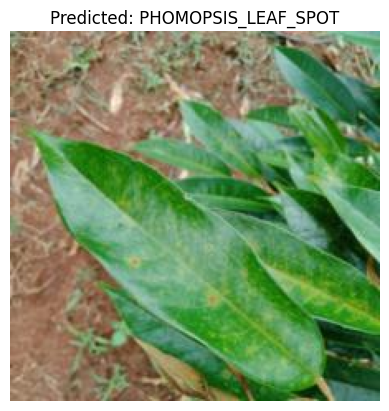

In [28]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import timm

# Function to load the saved model
def load_model(model_path='best_model_resnet101.pth', num_classes=5):
    model = timm.create_model('resnet101', pretrained=True, num_classes=num_classes)
    model.load_state_dict(torch.load(model_path))  # Load the best saved model
    model.eval()  # Set the model to evaluation mode
    return model

# Function to predict a single image
def predict_image(image_path, model, device):
    # Define the transformations to apply the same preprocessing as during training
    transform = transforms.Compose([
        transforms.Resize((224, 224)),  # Resize the image to match the model's input size
        transforms.ToTensor(),  # Convert the image to a tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize the image
    ])
    
    # Open and transform the image
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0)  # Add batch dimension
    
    # Move the image tensor to the same device (GPU or CPU)
    image = image.to(device)
    model = model.to(device)
    
    # Perform the forward pass to get predictions
    with torch.no_grad():  # No need to compute gradients for inference
        outputs = model(image)
        _, preds = torch.max(outputs, 1)  # Get the predicted class with the highest score
    
    return preds.item()

# Function to display the image and predicted class
def display_prediction(image_path, predicted_class, class_names):
    # Open and display the image
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Predicted: {class_names[predicted_class]}")
    plt.show()

# Load the best model
model_path = 'best_model_resnet101.pth'  # Path to the saved model
class_names = ['ALGAL_LEAF_SPOT', 'ALLOCARIDARA_ATTACK', 'HEALTHY_LEAF', 'LEAF_BLIGHT', 'PHOMOPSIS_LEAF_SPOT']  # Replace with your actual class names
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model
model = load_model(model_path=model_path, num_classes=len(class_names))

# Predict a single image (replace with the path to your image)
image_path = '/kaggle/input/trunkd/DLD_FinalDataset_224_spit/train/PHOMOPSIS_LEAF_SPOT/to_label_3632.jpg'  # Provide the path to your image here

# Make prediction
predicted_class = predict_image(image_path, model, device)

# Display the image with predicted class
display_prediction(image_path, predicted_class, class_names)
